In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
#This dataset has 890 rows and 12 columns
#most of the columns has numeric datatype i.e int or float
#there are also some columns with object datatype which is an arbitary datatype
#we can also see that there are some NAN values present in few columns like Age, Cabin and Embarked*

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#1. There are 891 samples present in data
#2. The avg age of the pasengers travelling in Titanic is concentrated arround 30 yrs old
#3. Std
#4. Skew & CT


In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<AxesSubplot:>

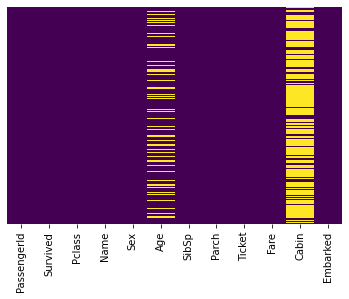

In [8]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")

<AxesSubplot:xlabel='Survived', ylabel='count'>

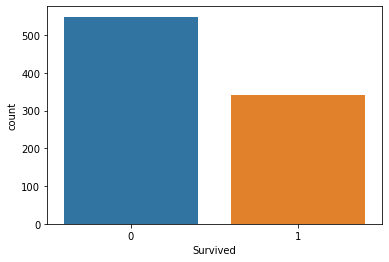

In [9]:
#what is the survival rate of titanic
sns.countplot(data=df, x="Survived")

<AxesSubplot:xlabel='Survived', ylabel='count'>

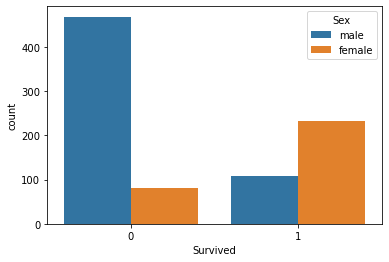

In [10]:
sns.countplot(data=df, x="Survived", hue="Sex")

<AxesSubplot:xlabel='Survived', ylabel='count'>

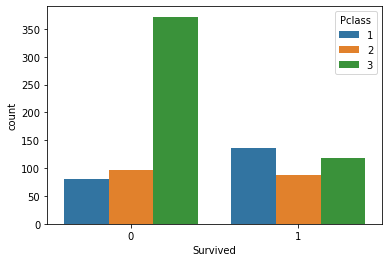

In [11]:
sns.countplot(data=df, x="Survived", hue="Pclass")

<AxesSubplot:xlabel='Fare', ylabel='Density'>

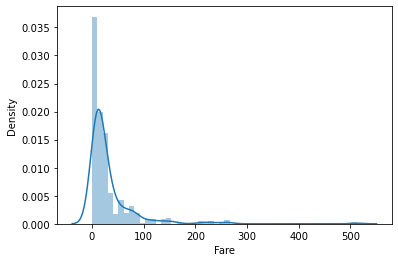

In [12]:
sns.distplot(df["Fare"])

<AxesSubplot:xlabel='Age', ylabel='Density'>

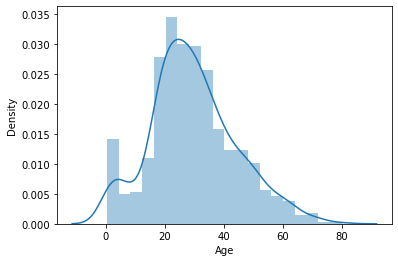

In [13]:
sns.distplot(df["Age"])

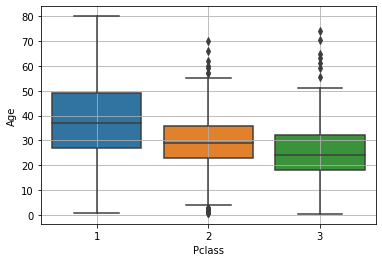

In [14]:
sns.boxplot(data=df, x="Pclass", y="Age")
plt.grid(True)

In [15]:
#apply

In [16]:
s = pd.Series(["Male", "Female", "Female", "Male"])
s

0      Male
1    Female
2    Female
3      Male
dtype: object

In [17]:
def gender(text):
  if text =="Male":
    return 1
  else:
    return 0

In [18]:
gender("Male")

1

In [19]:
s

0      Male
1    Female
2    Female
3      Male
dtype: object

In [20]:
s.apply(gender)

0    1
1    0
2    0
3    1
dtype: int64

In [21]:
s

0      Male
1    Female
2    Female
3      Male
dtype: object

In [22]:
s = s.apply(gender)

In [23]:
s

0    1
1    0
2    0
3    1
dtype: int64

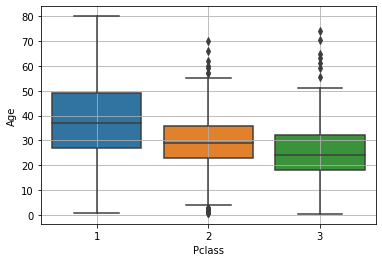

In [24]:
sns.boxplot(data=df, x="Pclass", y="Age")
plt.grid(True)

In [25]:
def fillage(cols):
  age = cols[0]
  pclass= cols[1]

  if(pd.isnull(age)):
    if(pclass==1):
      return 38
    elif(pclass==2):
      return 29
    else:
      return 24
  else:
    return age


In [26]:
df["Age"] = df[["Age", "Pclass"]].apply(fillage, axis=1)

<AxesSubplot:>

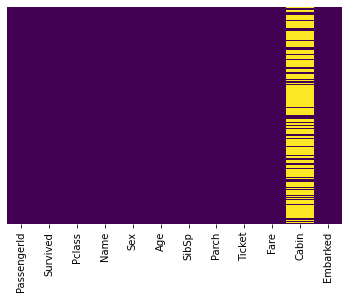

In [27]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")

In [28]:
df.drop("Cabin", axis=1, inplace=True)

<AxesSubplot:>

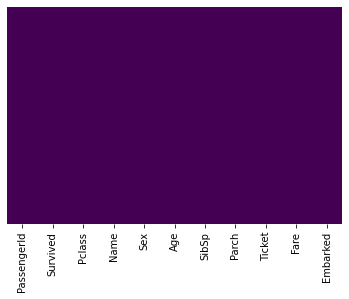

In [29]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")

In [30]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [31]:
df.dropna(inplace=True)

In [32]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [35]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [36]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [37]:
df["Embarked"].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [38]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [39]:
le = LabelEncoder()
ohe = OneHotEncoder()
oe = OrdinalEncoder()

In [40]:
ohe.fit_transform(df[["Sex", "Embarked"]]).toarray()

array([[0., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 0.],
       [0., 1., 0., 1., 0.]])

In [41]:
ohe.categories_

[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

In [42]:
#le.fit_transform(df[["Sex", "Embarked"]])

In [43]:
oe.fit_transform(df[["Sex", "Embarked"]])

array([[1., 2.],
       [0., 0.],
       [0., 2.],
       ...,
       [0., 2.],
       [1., 0.],
       [1., 1.]])

In [44]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,24.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [45]:
x = df.iloc[:, 1:] #2D
y = df.iloc[:, 0]  #1D

In [46]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,24.0,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [47]:
from sklearn.compose import ColumnTransformer

In [48]:
ct = ColumnTransformer(
    transformers=[
                 (
                     "encoder",
                  OrdinalEncoder(),
                  ["Sex", "Embarked"]
                 )
    ],
    remainder="passthrough"
)

x = ct.fit_transform(x)

In [49]:
x

array([[ 1.    ,  2.    ,  3.    , ...,  1.    ,  0.    ,  7.25  ],
       [ 0.    ,  0.    ,  1.    , ...,  1.    ,  0.    , 71.2833],
       [ 0.    ,  2.    ,  3.    , ...,  0.    ,  0.    ,  7.925 ],
       ...,
       [ 0.    ,  2.    ,  3.    , ...,  1.    ,  2.    , 23.45  ],
       [ 1.    ,  0.    ,  1.    , ...,  0.    ,  0.    , 30.    ],
       [ 1.    ,  1.    ,  3.    , ...,  0.    ,  0.    ,  7.75  ]])

In [50]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64

In [51]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.3, random_state=1)

In [52]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(xtrain, ytrain)

KNeighborsClassifier()

In [53]:
train = knn.score(xtrain, ytrain)
test = knn.score(xtest, ytest)

print(f"Training score : {train}")
print(f"Testing score : {test}")

Training score : 0.7829581993569131
Testing score : 0.6966292134831461


In [54]:
#low bias & high variance => Overfitting

In [55]:
trainac = []
testac = []

for i in range(1,31):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(xtrain, ytrain)

  trainac.append(knn.score(xtrain, ytrain))
  testac.append(knn.score(xtest, ytest))

In [56]:
dic = {
    "n":np.arange(1,31),
    "train":trainac,
    "test":testac
}

hp = pd.DataFrame(dic)
hp

,n,train,test
0,1,0.985531,0.704120
1,2,0.821543,0.666667
2,3,0.842444,0.692884
3,4,0.786174,0.670412
4,5,0.782958,0.696629
5,6,0.763666,0.662921
6,7,0.763666,0.677903
7,8,0.754019,0.681648
8,9,0.758842,0.666667
9,10,0.745981,0.670412


In [57]:
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(xtrain, ytrain)
ypred = knn.predict(xtest)

In [58]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.74      0.82      0.77       166
           1       0.63      0.51      0.57       101

    accuracy                           0.70       267
   macro avg       0.68      0.67      0.67       267
weighted avg       0.70      0.70      0.70       267



In [59]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(xtrain, ytrain)
ypred = logreg.predict(xtest)

In [60]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87       166
           1       0.79      0.80      0.79       101

    accuracy                           0.84       267
   macro avg       0.83      0.83      0.83       267
weighted avg       0.84      0.84      0.84       267



In [61]:
logreg.score(xtrain, ytrain)

0.7909967845659164

In [62]:
logreg.score(xtest, ytest)

0.8426966292134831

In [63]:
df.Survived.value_counts()

0    549
1    340
Name: Survived, dtype: int64

In [64]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.3, random_state=1, stratify=y)

In [65]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(xtrain, ytrain)

train = logreg.score(xtrain, ytrain)
test = logreg.score(xtest, ytest)

print(f"Training score : {train}")
print(f"Testing score : {test}")

Training score : 0.8038585209003215
Testing score : 0.8052434456928839


In [66]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(xtrain, ytrain)
ypred = svm.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.69      0.92      0.79       165
           1       0.72      0.32      0.45       102

    accuracy                           0.69       267
   macro avg       0.70      0.62      0.62       267
weighted avg       0.70      0.69      0.66       267



In [67]:
train = svm.score(xtrain, ytrain)
test = svm.score(xtest, ytest)

print(f"Training score : {train}")
print(f"Testing score : {test}")

Training score : 0.6752411575562701
Testing score : 0.6928838951310862


In [68]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.transform(xtest)

In [69]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(xtrain, ytrain)
ypred = svm.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       165
           1       0.85      0.71      0.77       102

    accuracy                           0.84       267
   macro avg       0.84      0.81      0.82       267
weighted avg       0.84      0.84      0.84       267

